# Bandit Problem

In [1]:
# imports
from bandits import Bandit
import random
# Include your imports here, if any are used. 
import numpy as np
import matplotlib.pyplot as plt


A bandit is one option (or “arm”) you can choose, where the reward you get is uncertain and must be learned by trying it out.
In multi-armed bandits, you repeatedly pick among several such uncertain options to find which one pays best.

A list of ten bandit objects initialized in the list...

In [2]:
bandits = [Bandit(random.random()*4-2) for _ in range(10)]


To generate reward from that bandit, use the pullLever() command

In [3]:
bandits[0].pullLever()



0.9463245349764745

## Greedy algorithm Implementation

In [4]:
def run_greedy(n_iter=1000):
    n_bandits = len(bandits)
    q = np.zeros(n_bandits)   
    n = np.zeros(n_bandits)   
    rewards = []
    for _ in range(n_iter):
        i = np.argmax(q)              
        r = bandits[i].pullLever()    
        rewards.append(r)
        n[i] += 1
        q[i] += (r - q[i]) / n[i]     
    return rewards


Plot the cumulative average of rewards as the number of iterations increases. and display that image below.

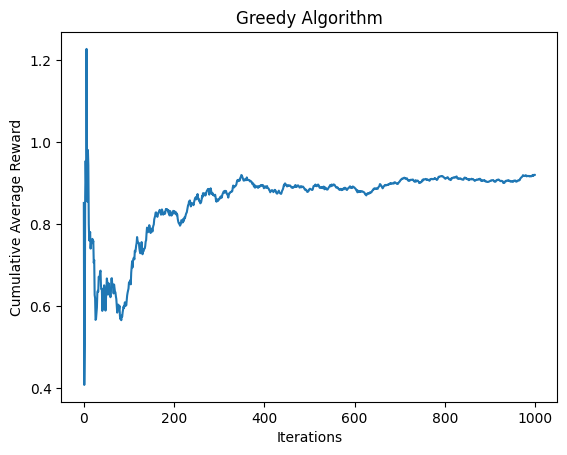

In [5]:
rewards = run_greedy(1000)
cum_avg = np.cumsum(rewards) / (np.arange(len(rewards)) + 1)
plt.plot(cum_avg)
plt.xlabel("Iterations")
plt.ylabel("Cumulative Average Reward")
plt.title("Greedy Algorithm")
plt.show()


## $\epsilon$-greedy Algorithm

In [6]:
def run_epsilon_greedy(epsilon, n_iter=1000):
    n_bandits = len(bandits)
    Q = np.zeros(n_bandits)
    N = np.zeros(n_bandits)
    rewards = []
    for _ in range(n_iter):
        if np.random.rand() < epsilon:
            i = np.random.randint(n_bandits)
        else:
            i = np.argmax(Q)
        r = bandits[i].pullLever()
        rewards.append(r)
        N[i] += 1
        Q[i] += (r - Q[i]) / N[i]
    return rewards


Plot the cumulative average of rewards as the number of iterations increases but for various values of $\epsilon$.

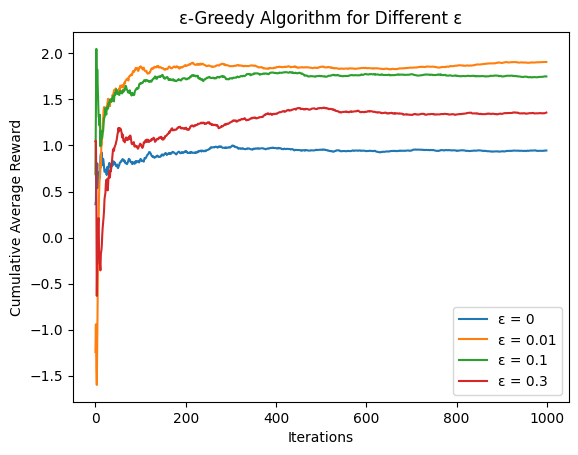

In [7]:
import matplotlib.pyplot as plt
import numpy as np
epsilons = [0, 0.01, 0.1, 0.3]
n_iter = 1000
for eps in epsilons:
    rewards = run_epsilon_greedy(eps, n_iter)
    cum_avg = np.cumsum(rewards) / (np.arange(n_iter) + 1)
    plt.plot(cum_avg, label=f"ε = {eps}")
plt.xlabel("Iterations")
plt.ylabel("Cumulative Average Reward")
plt.title("ε-Greedy Algorithm for Different ε")
plt.legend()
plt.show()


## Finding the optimal $\epsilon$

Run the $\epsilon$-greedy algorithm for 1000 iterations and find the optimal $\epsilon$ value by plotting the cumulative average of rewards for various values of $\epsilon$

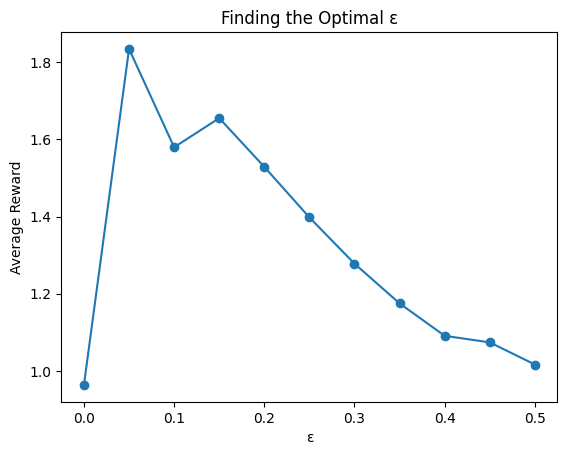

In [8]:
epsilons = np.linspace(0, 0.5, 11)
n_iter = 1000
avg_rewards = []
for eps in epsilons:
    rewards = run_epsilon_greedy(eps, n_iter)
    avg_rewards.append(np.mean(rewards))
plt.plot(epsilons, avg_rewards, marker='o')
plt.xlabel("ε")
plt.ylabel("Average Reward")
plt.title("Finding the Optimal ε")
plt.show()


## Optimistic Initial Values

In [9]:
def run_optimistic_greedy(Q_init=10, n_iter=1000):
    n_bandits = len(bandits)
    q = np.ones(n_bandits) * q_init
    n = np.zeros(n_bandits)
    rewards = []
    for _ in range(n_iter):
        i = np.argmax(q)
        r = bandits[i].pullLever()
        rewards.append(r)
        n[i] += 1
        q[i] += (r - q[i]) / n[i]
    return rewards

Plot the cumulative average of rewards as the number of iterations increases for an optimistic greedy of $Q_1 = 10$ and a non-optimistic $\epsilon = 0.1$ and try to compare which is better.

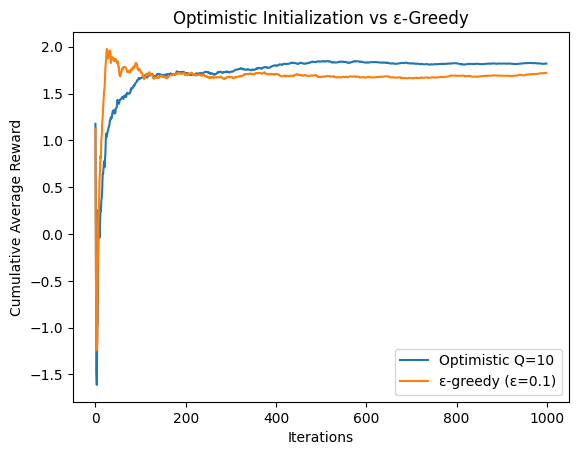

In [10]:
n_iter = 1000
r_opt = run_optimistic_greedy(Q_init=10, n_iter=n_iter)
r_eps = run_epsilon_greedy(0.1, n_iter)
plt.plot(np.cumsum(r_opt)/(np.arange(n_iter)+1), label="Optimistic Q=10")
plt.plot(np.cumsum(r_eps)/(np.arange(n_iter)+1), label="ε-greedy (ε=0.1)")
plt.xlabel("Iterations")
plt.ylabel("Cumulative Average Reward")
plt.title("Optimistic Initialization vs ε-Greedy")
plt.legend()
plt.show()

## Upper Confidence Bound (UCB)

In [11]:
def run_ucb(c, n_iter=1000):
    n_bandits = len(bandits)
    Q = np.zeros(n_bandits)
    N = np.zeros(n_bandits)
    rewards = []
    for t in range(1, n_iter + 1):
        ucb_values = np.zeros(n_bandits)

        for i in range(n_bandits):
            if N[i] == 0:
                ucb_values[i] = float('inf')
            else:
                ucb_values[i] = Q[i] + c * np.sqrt(np.log(t) / N[i])
        i = np.argmax(ucb_values)
        r = bandits[i].pullLever()
        rewards.append(r)
        N[i] += 1
        Q[i] += (r - Q[i]) / N[i]
    return rewards

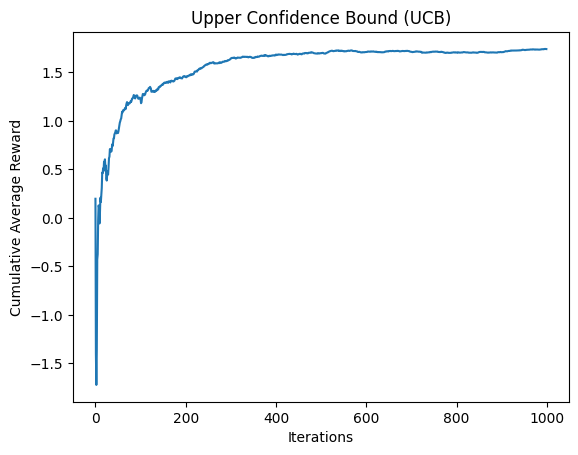

In [12]:
n_iter = 1000
rewards = run_ucb(c=2, n_iter=n_iter)
plt.plot(np.cumsum(rewards)/(np.arange(n_iter)+1))
plt.xlabel("Iterations")
plt.ylabel("Cumulative Average Reward")
plt.title("Upper Confidence Bound (UCB)")
plt.show()